In [39]:
#!unzip results.zip

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Directory containing CSV files
RESULTS_DIR = "results/attack/025flipped"  # Change this to your results directory
# RESULTS_DIR = "results/no_attack"  # Uncomment for clean training

# Poisoned client IDs (1-indexed to match your client directories)
POISONED_CLIENTS = [3, 17]  # Change based on your experiment



In [41]:
def load_metrics(results_dir):
    """Load all metrics CSV files."""
    results_path = Path(results_dir)

    try:
        client_losses = pd.read_csv(results_path / "client_losses.csv")
        client_accuracies = pd.read_csv(results_path / "client_accuracies.csv")
        avg_losses = pd.read_csv(results_path / "avg_losses.csv")
        avg_accuracies = pd.read_csv(results_path / "avg_accuracies.csv")

        if 'client_id' in client_losses.columns:
            client_losses['client_id'] = client_losses['client_id'] - 1
        if 'client_id' in client_accuracies.columns:
            client_accuracies['client_id'] = client_accuracies['client_id'] - 1

        avg_accuracies = avg_accuracies[avg_accuracies['avg_accuracy'] > 0.0].copy()
        avg_losses = avg_losses[avg_losses['round'].isin(avg_accuracies['round'])].copy()

        print(f"✅ Successfully loaded metrics from: {results_dir}")
        print(f"   - Client losses: {len(client_losses)} records")
        print(f"   - Client accuracies: {len(client_accuracies)} records")
        print(f"   - Avg losses: {len(avg_losses)} records")
        print(f"   - Avg accuracies: {len(avg_accuracies)} records")

        return client_losses, client_accuracies, avg_losses, avg_accuracies
    except FileNotFoundError as e:
        print(f"❌ Error: Could not find CSV files in {results_dir}")
        print(f"   Make sure the directory exists and contains the CSV files.")
        raise e

In [42]:
def plot_average_metrics(avg_losses, avg_accuracies, save_path=None):
    """Plot average loss and accuracy across all clients over rounds."""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    eval_accuracies = avg_accuracies[avg_accuracies['avg_accuracy'] > 0.0].copy()
    eval_losses = avg_losses[avg_losses['round'].isin(eval_accuracies['round'])].copy()

    # Plot 1: Average Loss
    ax1.plot(eval_losses['round'], eval_losses['avg_loss'],
             marker='o', linewidth=2, markersize=8, label='Average Loss')
    ax1.set_xlabel('Round', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax1.set_title('Average Loss Across All Clients', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11)

    # Plot 2: Average Accuracy
    ax2.plot(eval_accuracies['round'], eval_accuracies['avg_accuracy'],
             marker='s', linewidth=2, markersize=8, color='green', label='Average Accuracy')
    ax2.set_xlabel('Round', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax2.set_title('Average Accuracy Across All Clients', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1])
    ax2.legend(fontsize=11)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"💾 Saved: {save_path}")

    plt.show()

In [43]:
# PLOT 2: Individual Client Performance

def plot_client_performance(client_accuracies, poisoned_clients=None, save_path=None):
    """Plot accuracy for each client over rounds."""

    # Remove aggregate rows (client_id = -1)
    client_data = client_accuracies[client_accuracies['client_id'] != -1].copy()

    # Identify poisoned vs clean clients
    if poisoned_clients:
        client_data['is_poisoned'] = client_data['client_id'].isin(poisoned_clients)
    else:
        client_data['is_poisoned'] = False

    fig, ax = plt.subplots(figsize=(16, 8))

    # Plot each client
    unique_clients = sorted(client_data['client_id'].unique())

    for client_id in unique_clients:
        client_subset = client_data[client_data['client_id']-1 == client_id-1]
        is_poisoned = client_subset['is_poisoned'].iloc[0] if len(client_subset) > 0 else False

        if is_poisoned:
            ax.plot(client_subset['round'], client_subset['accuracy'],
                   marker='x', linewidth=2, linestyle='--', alpha=0.7,
                   label=f'Client {client_id} (Poisoned)', color='red')
        else:
            ax.plot(client_subset['round'], client_subset['accuracy'],
                   marker='o', linewidth=1.5, alpha=0.6,
                   label=f'Client {client_id}')

    ax.set_xlabel('Round', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Individual Client Accuracy Over Rounds', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=2)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"💾 Saved: {save_path}")

    plt.show()







In [44]:
# PLOT 3: Poisoned vs Clean Client Comparison

def plot_poisoned_vs_clean(client_accuracies, poisoned_clients, save_path=None):
    """Compare poisoned vs clean client performance."""

    if not poisoned_clients:
        print("⚠️ No poisoned clients specified. Skipping this plot.")
        return

    client_data = client_accuracies[client_accuracies['client_id'] != -1].copy()

    # Separate poisoned and clean clients
    client_data['group'] = client_data['client_id'].apply(
        lambda x: 'Poisoned' if x in poisoned_clients else 'Clean'
    )

    # Calculate average accuracy per round for each group
    group_avg = client_data.groupby(['round', 'group'])['accuracy'].mean().reset_index()

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot each group
    for group in ['Clean', 'Poisoned']:
        group_data = group_avg[group_avg['group'] == group]
        color = 'red' if group == 'Poisoned' else 'green'
        marker = 'x' if group == 'Poisoned' else 'o'
        ax.plot(group_data['round'], group_data['accuracy'],
               marker=marker, linewidth=2.5, markersize=10,
               label=f'{group} Clients', color=color)

    ax.set_xlabel('Round', fontsize=12, fontweight='bold')
    ax.set_ylabel('Average Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Poisoned vs Clean Client Performance', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])
    ax.legend(fontsize=12)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"💾 Saved: {save_path}")

    plt.show()




In [45]:
# PLOT 4: Final Round Performance Heatmap

def plot_final_round_heatmap(client_accuracies, poisoned_clients=None, save_path=None):
    """Show final round accuracy for all clients as a heatmap."""

    # Remove aggregate rows
    client_data = client_accuracies[client_accuracies['client_id'] != -1].copy()

    # Get final round
    final_round = client_data['round'].max()
    final_data = client_data[client_data['round'] == final_round].copy()
    final_data = final_data.sort_values('client_id')

    # Create labels with poisoned indicator
    if poisoned_clients:
        final_data['label'] = final_data['client_id'].apply(
            lambda x: f"Client {x} ⚠️" if x in poisoned_clients else f"Client {x}"
        )
    else:
        final_data['label'] = final_data['client_id'].apply(lambda x: f"Client {x}")

    # Create heatmap data
    accuracy_data = final_data['accuracy'].values.reshape(1, -1)

    fig, ax = plt.subplots(figsize=(16, 3))

    # Create heatmap
    im = ax.imshow(accuracy_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

    # Set ticks and labels
    ax.set_xticks(np.arange(len(final_data)))
    ax.set_xticklabels(final_data['label'], rotation=45, ha='right')
    ax.set_yticks([0])
    ax.set_yticklabels([f'Round {final_round}'])

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Accuracy', rotation=270, labelpad=20, fontsize=12, fontweight='bold')

    # Add text annotations
    for i, acc in enumerate(accuracy_data[0]):
        text_color = 'white' if acc < 0.5 else 'black'
        ax.text(i, 0, f'{acc:.3f}', ha='center', va='center',
               color=text_color, fontsize=9, fontweight='bold')

    ax.set_title(f'Final Round ({final_round}) Accuracy by Client',
                fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"💾 Saved: {save_path}")

    plt.show()

In [46]:
# PLOT 5: Box Plot - Accuracy Distribution

def plot_accuracy_distribution(client_accuracies, poisoned_clients=None, save_path=None):
    """Show distribution of accuracy across rounds for poisoned vs clean clients."""

    # Remove aggregate rows
    client_data = client_accuracies[client_accuracies['client_id'] != -1].copy()

    if poisoned_clients:
        client_data['group'] = client_data['client_id'].apply(
            lambda x: 'Poisoned' if x in poisoned_clients else 'Clean'
        )
    else:
        client_data['group'] = 'All Clients'

    fig, ax = plt.subplots(figsize=(10, 6))

    # Create box plot
    if poisoned_clients:
        sns.boxplot(data=client_data, x='round', y='accuracy', hue='group',
                   palette={'Clean': 'green', 'Poisoned': 'red'}, ax=ax)
    else:
        sns.boxplot(data=client_data, x='round', y='accuracy', ax=ax)

    ax.set_xlabel('Round', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Accuracy Distribution by Round', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"💾 Saved: {save_path}")

    plt.show()


In [47]:
# PLOT 6: Loss Evolution for Individual Clients

def plot_client_losses(client_losses, poisoned_clients=None, save_path=None):
    """Plot loss evolution for each client."""

    # Remove aggregate rows
    client_data = client_losses[client_losses['client_id'] != -1].copy()

    # Identify poisoned vs clean clients
    if poisoned_clients:
        client_data['is_poisoned'] = client_data['client_id'].isin(poisoned_clients)
    else:
        client_data['is_poisoned'] = False

    fig, ax = plt.subplots(figsize=(16, 8))

    # Plot each client
    unique_clients = sorted(client_data['client_id'].unique())

    for client_id in unique_clients:
        client_subset = client_data[client_data['client_id'] == client_id]
        is_poisoned = client_subset['is_poisoned'].iloc[0] if len(client_subset) > 0 else False

        if is_poisoned:
            ax.plot(client_subset['round'], client_subset['loss'],
                   marker='x', linewidth=2, linestyle='--', alpha=0.7,
                   label=f'Client {client_id} (Poisoned)', color='red')
        else:
            ax.plot(client_subset['round'], client_subset['loss'],
                   marker='o', linewidth=1.5, alpha=0.6,
                   label=f'Client {client_id}')

    ax.set_xlabel('Round', fontsize=12, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax.set_title('Individual Client Loss Over Rounds', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=2)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"💾 Saved: {save_path}")

    plt.show()


CIFAR-10 Federated Learning Visualization

✅ Successfully loaded metrics from: results/attack/025flipped
   - Client losses: 100 records
   - Client accuracies: 100 records
   - Avg losses: 10 records
   - Avg accuracies: 5 records

📁 Saving plots to: results/attack/025flipped/plots

📊 Generating plots...

💾 Saved: results/attack/025flipped/plots/1_average_metrics.png


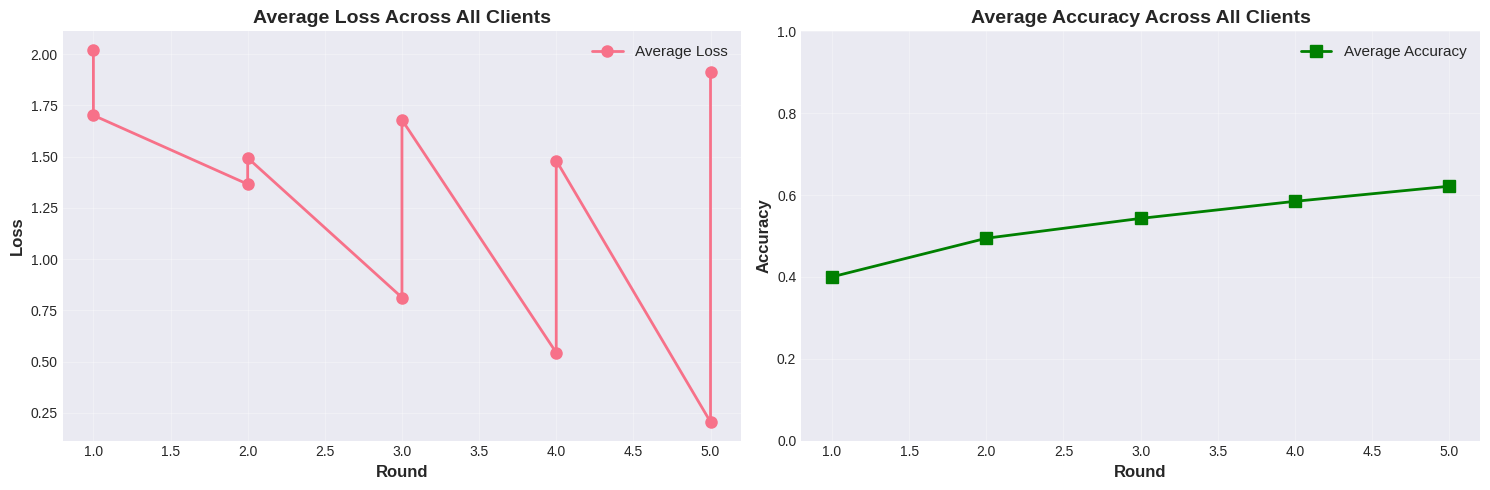

💾 Saved: results/attack/025flipped/plots/2_client_performance.png


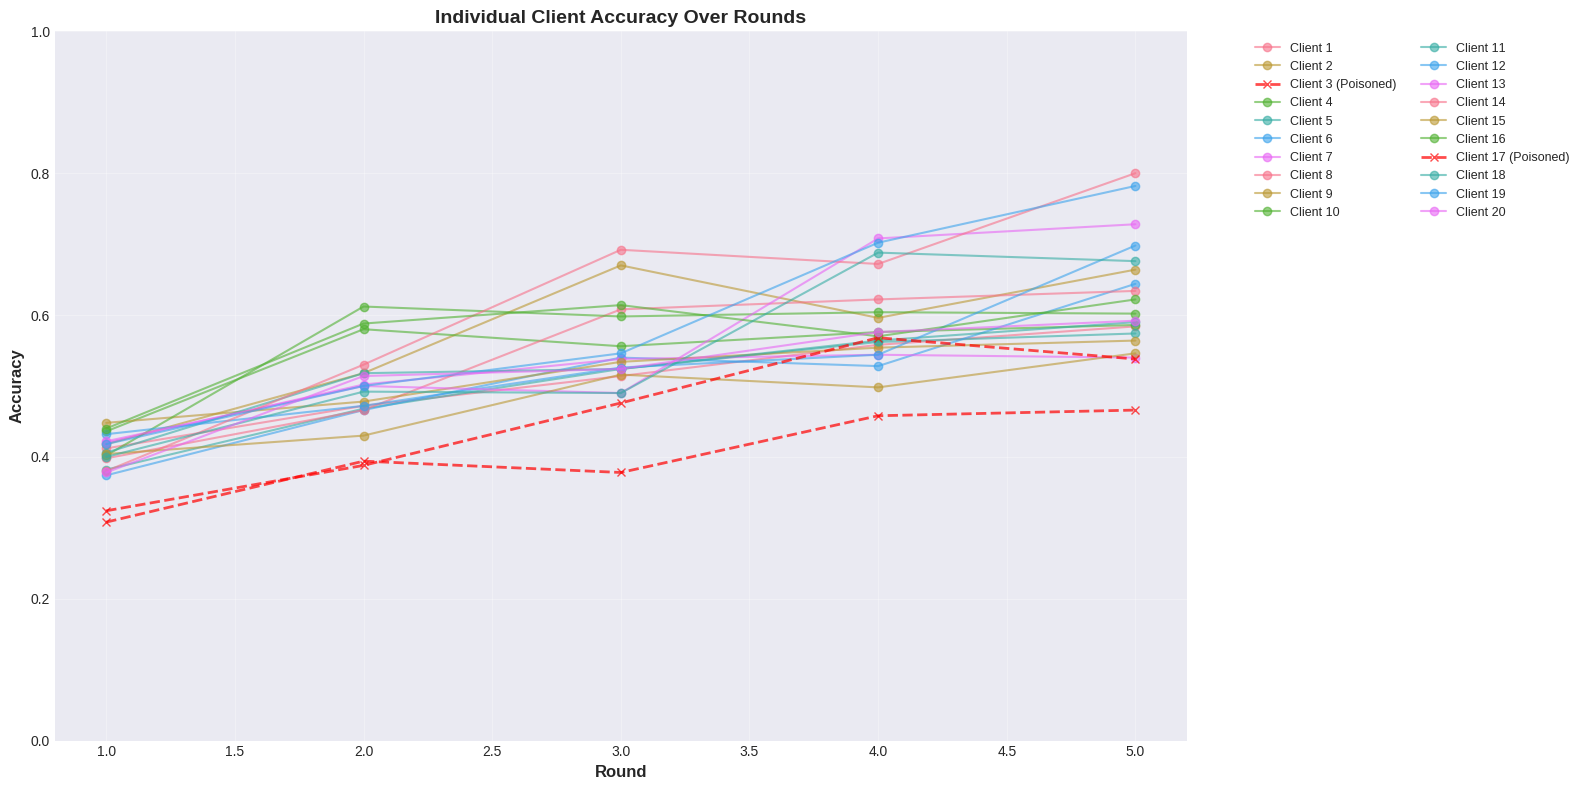

💾 Saved: results/attack/025flipped/plots/3_poisoned_vs_clean.png


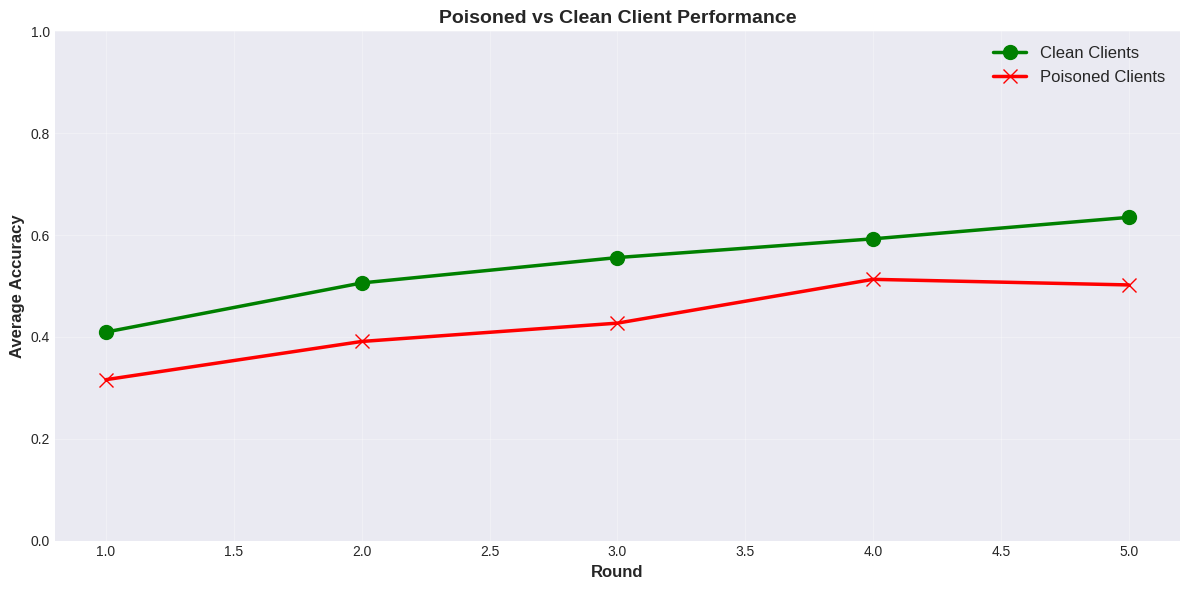

/tmp/ipython-input-3526526146.py:51: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3526526146.py:51: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3526526146.py:54: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipython-input-3526526146.py:54: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')


💾 Saved: results/attack/025flipped/plots/4_final_round_heatmap.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


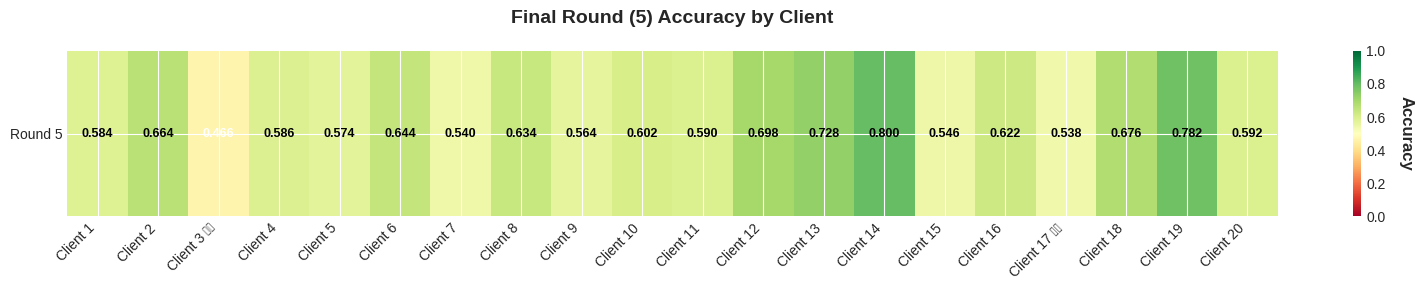

💾 Saved: results/attack/025flipped/plots/5_accuracy_distribution.png


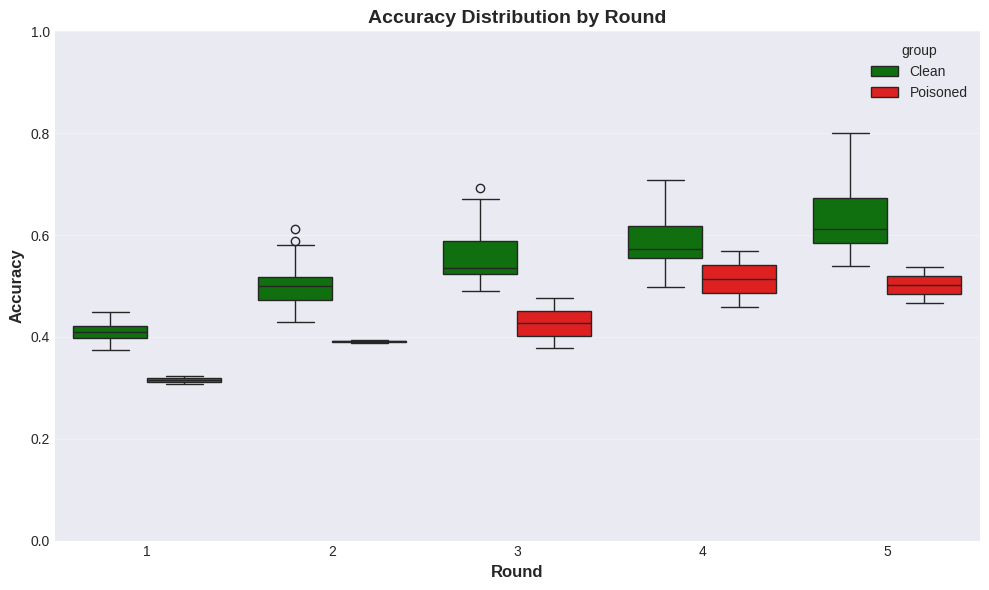

💾 Saved: results/attack/025flipped/plots/6_client_losses.png


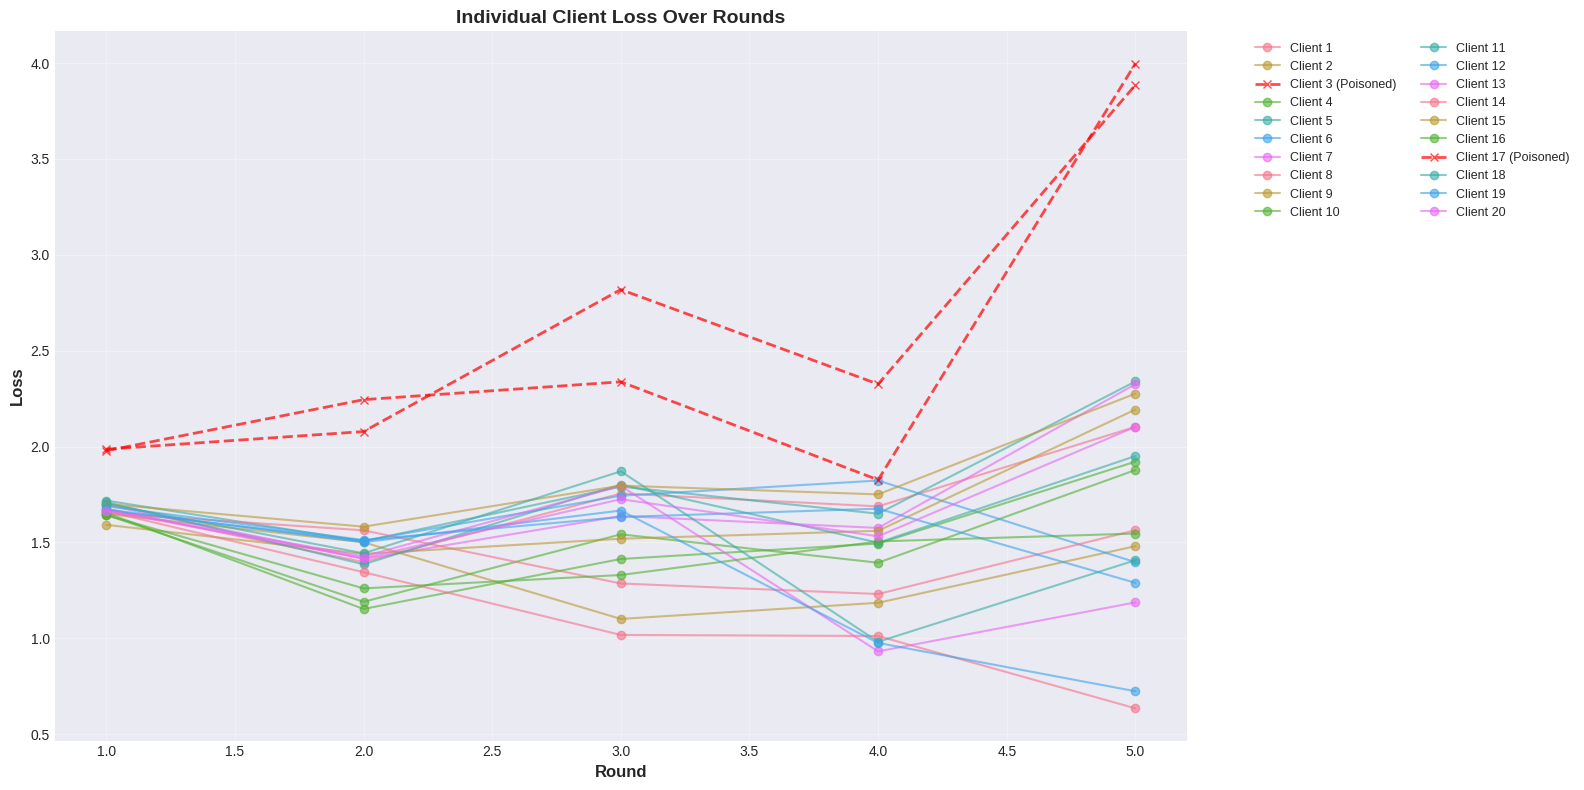


SUMMARY STATISTICS (Final Round)

🔴 Poisoned Clients (2 clients):
   Average Accuracy: 0.5020 ± 0.0509
   Min Accuracy: 0.4660
   Max Accuracy: 0.5380

🟢 Clean Clients (18 clients):
   Average Accuracy: 0.6348 ± 0.0767
   Min Accuracy: 0.5400
   Max Accuracy: 0.8000

📊 Overall (20 clients):
   Average Accuracy: 0.6215 ± 0.0840
   Min Accuracy: 0.4660
   Max Accuracy: 0.8000

✅ All plots saved to: results/attack/025flipped/plots



In [48]:
# SUMMARY STATISTICS

def print_summary_statistics(client_accuracies, poisoned_clients=None):
    """Print summary statistics."""

    # Remove aggregate rows
    client_data = client_accuracies[client_accuracies['client_id'] != -1].copy()

    # Get final round data
    final_round = client_data['round'].max()
    final_data = client_data[client_data['round'] == final_round]

    print("\n" + "=" * 70)
    print("SUMMARY STATISTICS (Final Round)")
    print("=" * 70)

    if poisoned_clients:
        poisoned_data = final_data[final_data['client_id'].isin(poisoned_clients)]
        clean_data = final_data[~final_data['client_id'].isin(poisoned_clients)]

        print(f"\n🔴 Poisoned Clients ({len(poisoned_clients)} clients):")
        print(f"   Average Accuracy: {poisoned_data['accuracy'].mean():.4f} ± {poisoned_data['accuracy'].std():.4f}")
        print(f"   Min Accuracy: {poisoned_data['accuracy'].min():.4f}")
        print(f"   Max Accuracy: {poisoned_data['accuracy'].max():.4f}")

        print(f"\n🟢 Clean Clients ({len(clean_data)} clients):")
        print(f"   Average Accuracy: {clean_data['accuracy'].mean():.4f} ± {clean_data['accuracy'].std():.4f}")
        print(f"   Min Accuracy: {clean_data['accuracy'].min():.4f}")
        print(f"   Max Accuracy: {clean_data['accuracy'].max():.4f}")

        print(f"\n📊 Overall ({len(final_data)} clients):")
    else:
        print(f"\n📊 All Clients ({len(final_data)} clients):")

    print(f"   Average Accuracy: {final_data['accuracy'].mean():.4f} ± {final_data['accuracy'].std():.4f}")
    print(f"   Min Accuracy: {final_data['accuracy'].min():.4f}")
    print(f"   Max Accuracy: {final_data['accuracy'].max():.4f}")
    print("=" * 70 + "\n")

# MAIN EXECUTION

def main():
    """Main function to generate all plots."""

    print("\n" + "=" * 70)
    print("CIFAR-10 Federated Learning Visualization")
    print("=" * 70 + "\n")

    # Load data
    client_losses, client_accuracies, avg_losses, avg_accuracies = load_metrics(RESULTS_DIR)

    # Create output directory for plots
    output_dir = Path(RESULTS_DIR) / "plots"
    output_dir.mkdir(exist_ok=True)
    print(f"\n📁 Saving plots to: {output_dir}\n")

    # Generate all plots
    print("📊 Generating plots...\n")

    plot_average_metrics(avg_losses, avg_accuracies,
                        save_path=output_dir / "1_average_metrics.png")

    plot_client_performance(client_accuracies, POISONED_CLIENTS,
                          save_path=output_dir / "2_client_performance.png")

    if POISONED_CLIENTS:
        plot_poisoned_vs_clean(client_accuracies, POISONED_CLIENTS,
                             save_path=output_dir / "3_poisoned_vs_clean.png")

    plot_final_round_heatmap(client_accuracies, POISONED_CLIENTS,
                            save_path=output_dir / "4_final_round_heatmap.png")

    plot_accuracy_distribution(client_accuracies, POISONED_CLIENTS,
                             save_path=output_dir / "5_accuracy_distribution.png")

    plot_client_losses(client_losses, POISONED_CLIENTS,
                      save_path=output_dir / "6_client_losses.png")

    # Print summary statistics
    print_summary_statistics(client_accuracies, POISONED_CLIENTS)

    print(f"✅ All plots saved to: {output_dir}")
    print("=" * 70 + "\n")

# Run the visualization
if __name__ == "__main__":
    main()


CIFAR-10 Federated Learning Visualization

✅ Successfully loaded metrics from: results/attack/050flipped
   - Client losses: 100 records
   - Client accuracies: 100 records
   - Avg losses: 10 records
   - Avg accuracies: 5 records

📁 Saving plots to: results/attack/050flipped/plots

📊 Generating plots...

💾 Saved: results/attack/050flipped/plots/1_average_metrics.png


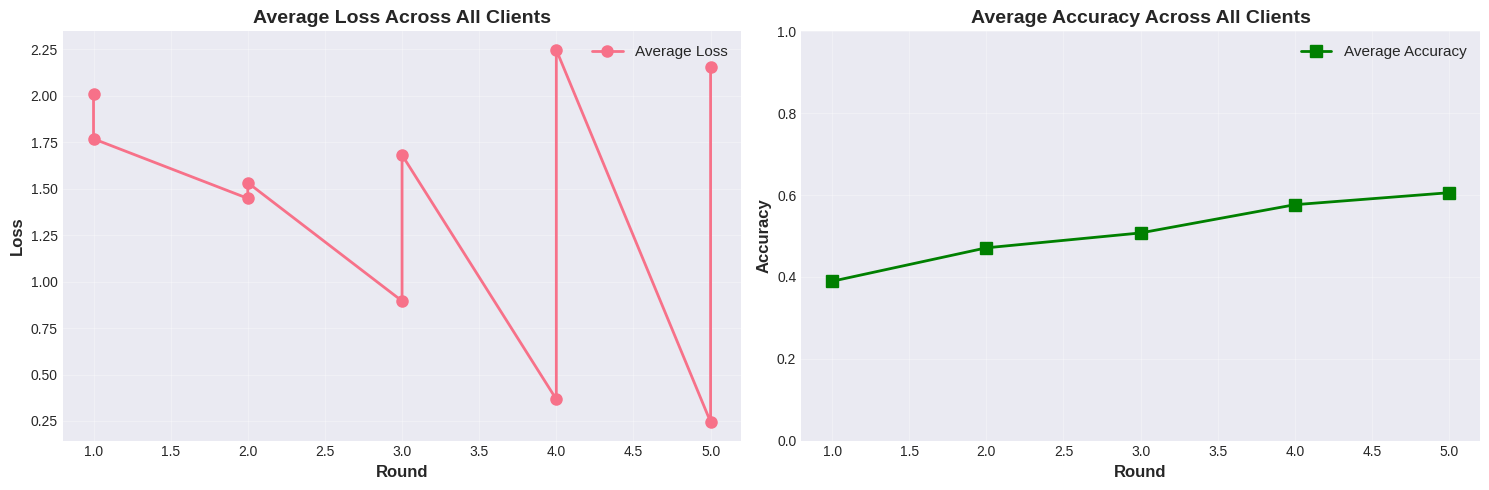

💾 Saved: results/attack/050flipped/plots/2_client_performance.png


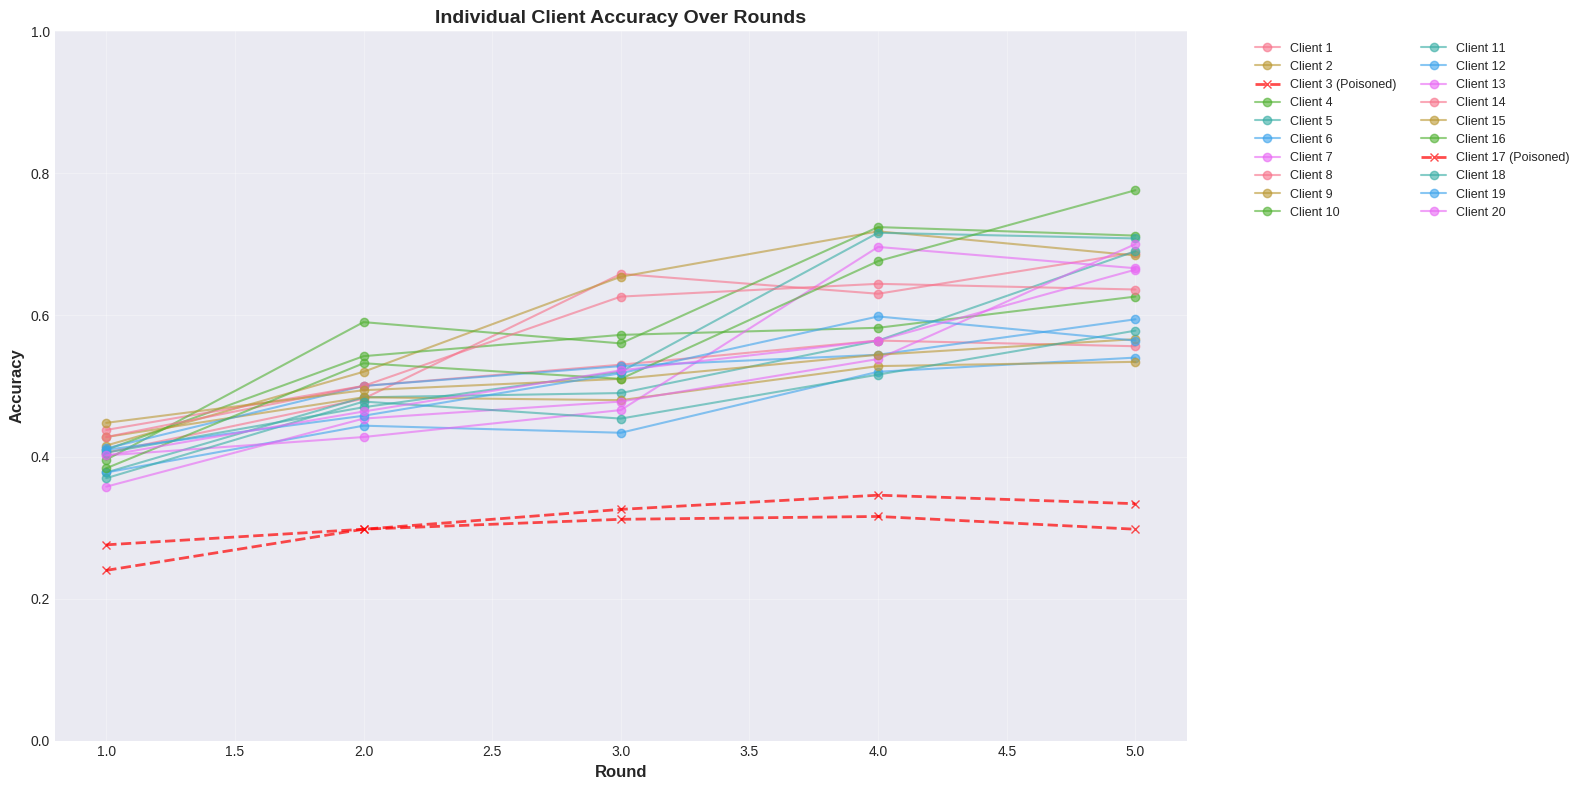

💾 Saved: results/attack/050flipped/plots/3_poisoned_vs_clean.png


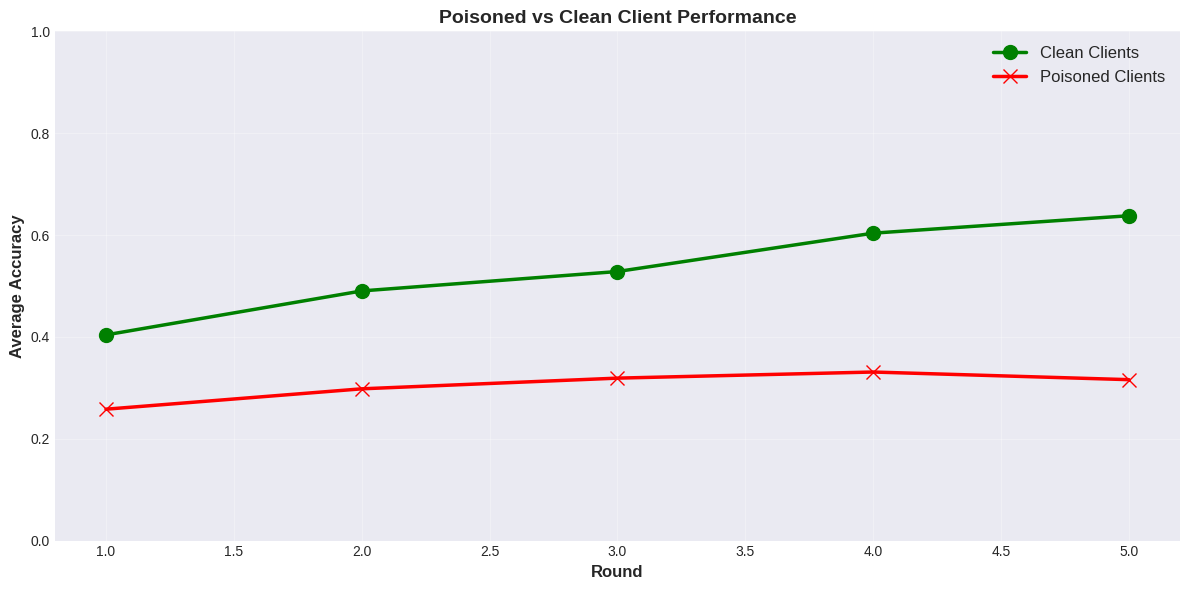

/tmp/ipython-input-3526526146.py:51: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3526526146.py:51: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3526526146.py:54: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipython-input-3526526146.py:54: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')


💾 Saved: results/attack/050flipped/plots/4_final_round_heatmap.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


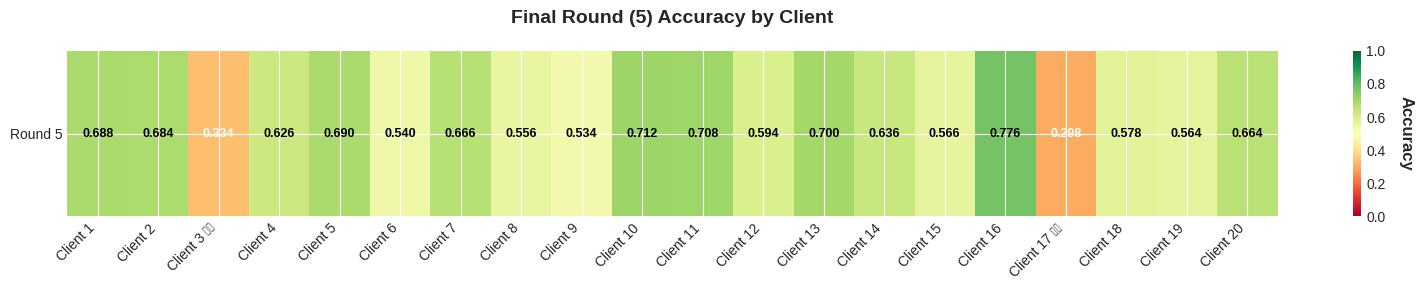

💾 Saved: results/attack/050flipped/plots/5_accuracy_distribution.png


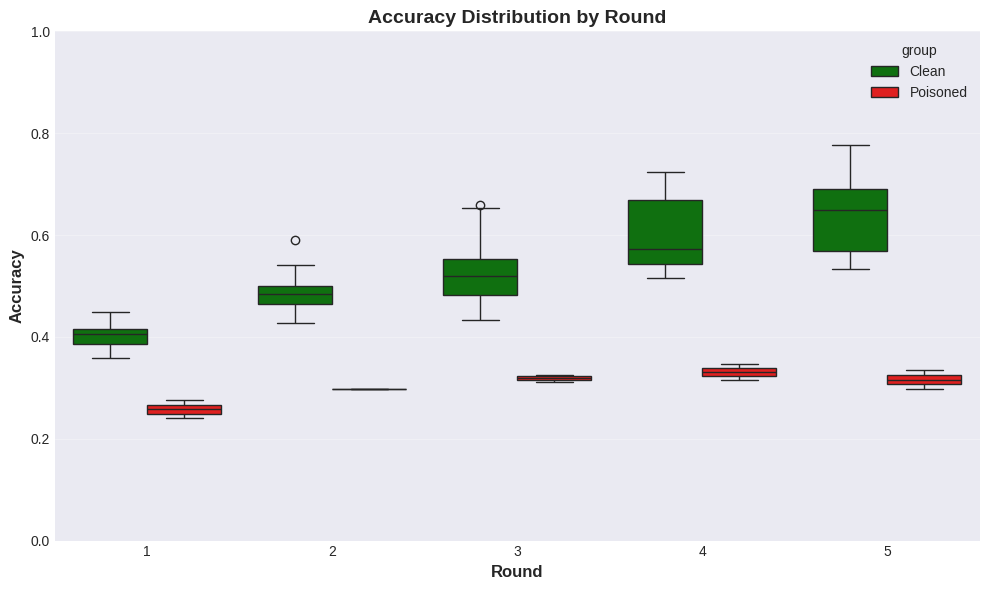

💾 Saved: results/attack/050flipped/plots/6_client_losses.png


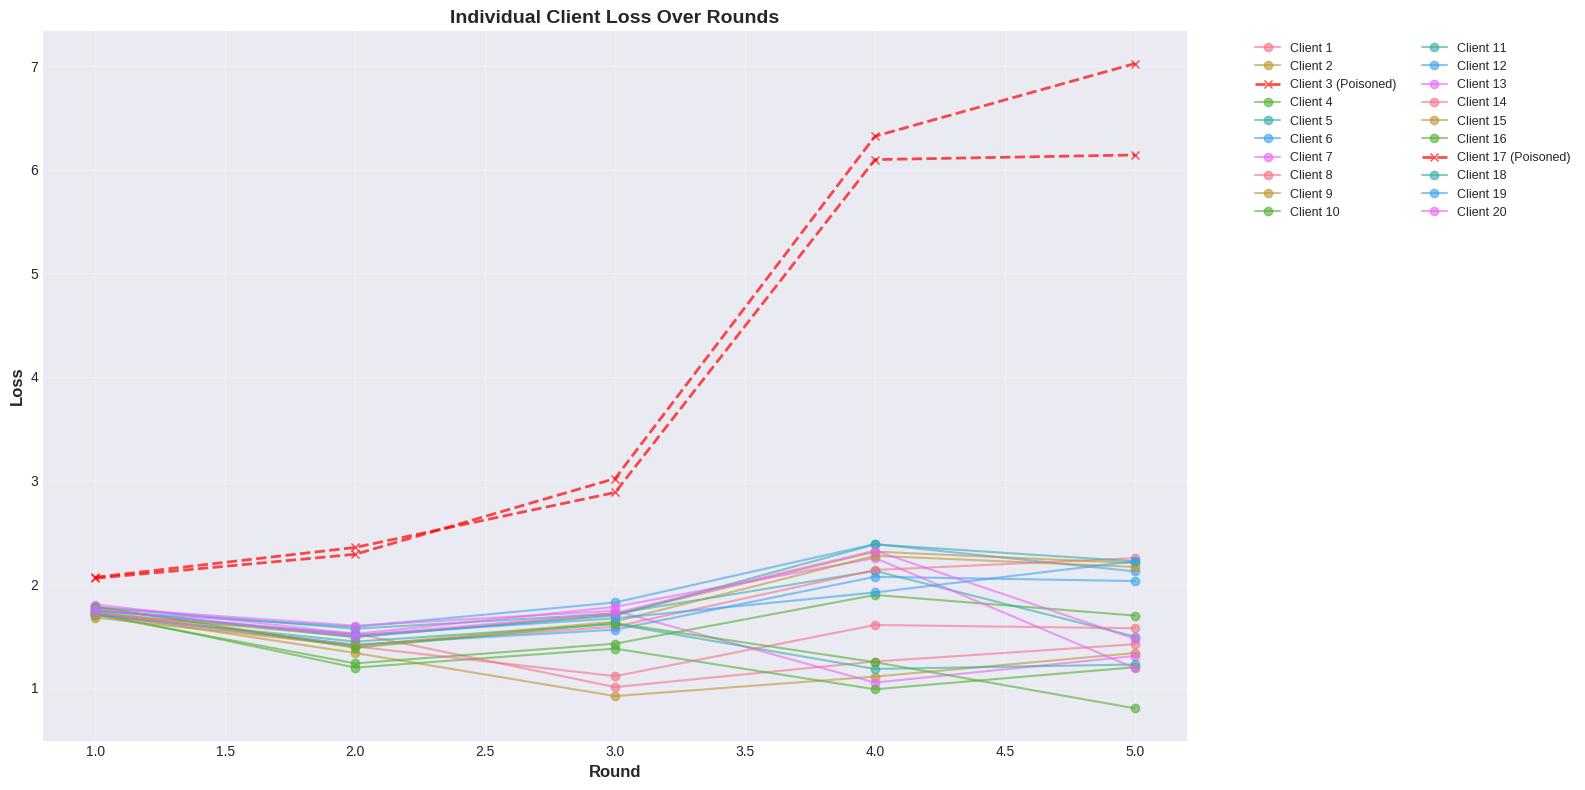


SUMMARY STATISTICS (Final Round)

🔴 Poisoned Clients (2 clients):
   Average Accuracy: 0.3160 ± 0.0255
   Min Accuracy: 0.2980
   Max Accuracy: 0.3340

🟢 Clean Clients (18 clients):
   Average Accuracy: 0.6379 ± 0.0709
   Min Accuracy: 0.5340
   Max Accuracy: 0.7760

📊 Overall (20 clients):
   Average Accuracy: 0.6057 ± 0.1198
   Min Accuracy: 0.2980
   Max Accuracy: 0.7760

✅ All plots saved to: results/attack/050flipped/plots



In [49]:
RESULTS_DIR = "results/attack/050flipped"
main()


CIFAR-10 Federated Learning Visualization

✅ Successfully loaded metrics from: results/attack/075flipped
   - Client losses: 100 records
   - Client accuracies: 100 records
   - Avg losses: 10 records
   - Avg accuracies: 5 records

📁 Saving plots to: results/attack/075flipped/plots

📊 Generating plots...

💾 Saved: results/attack/075flipped/plots/1_average_metrics.png


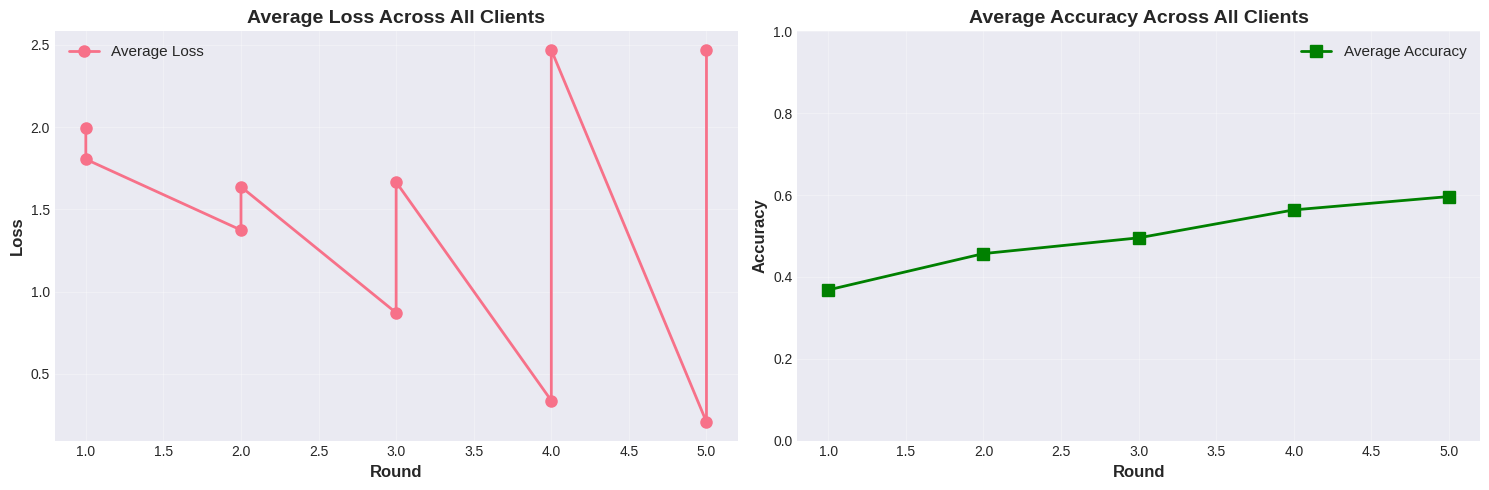

💾 Saved: results/attack/075flipped/plots/2_client_performance.png


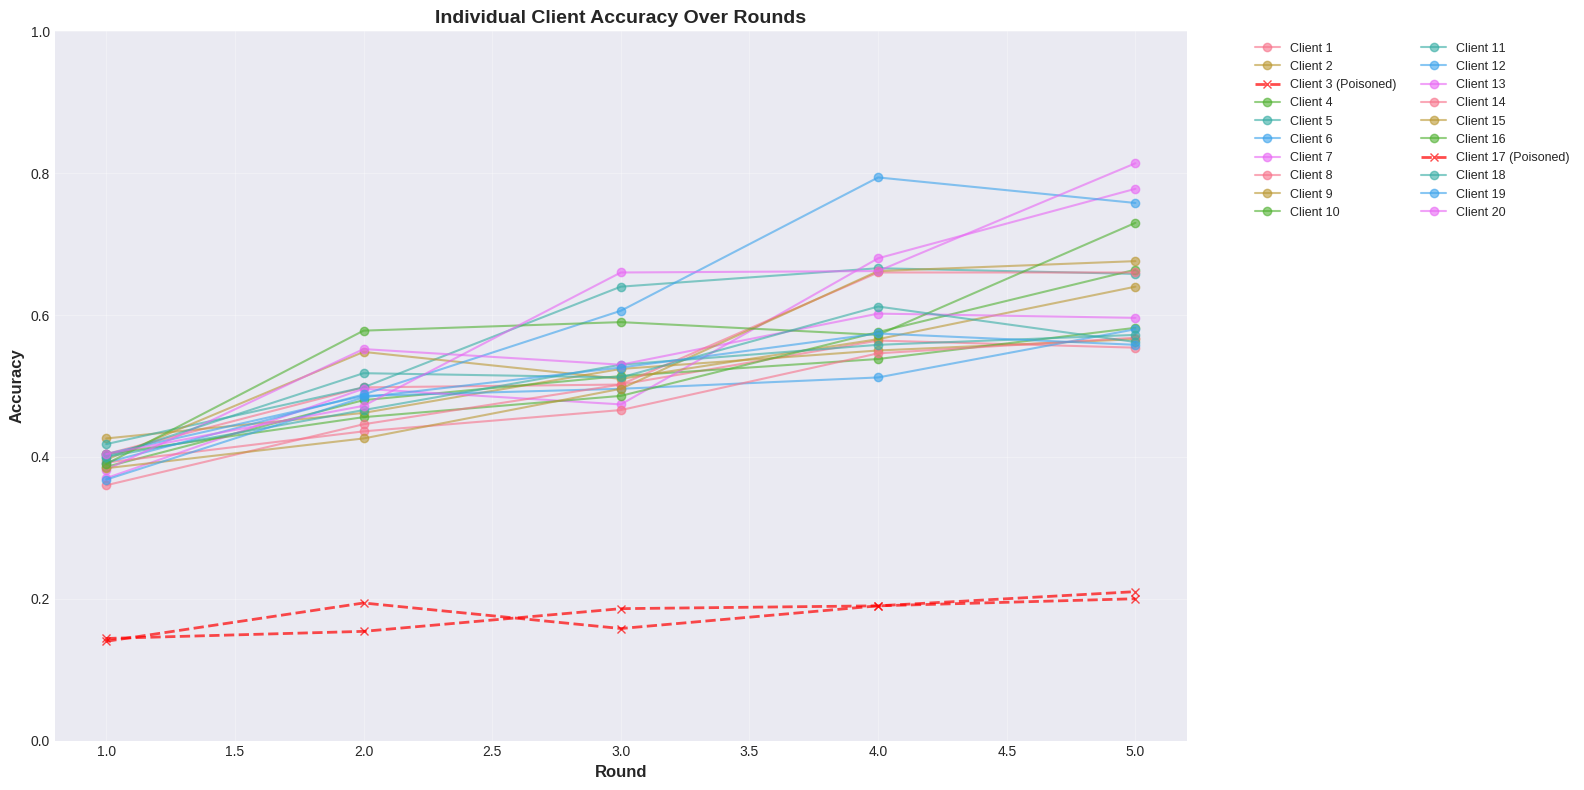

💾 Saved: results/attack/075flipped/plots/3_poisoned_vs_clean.png


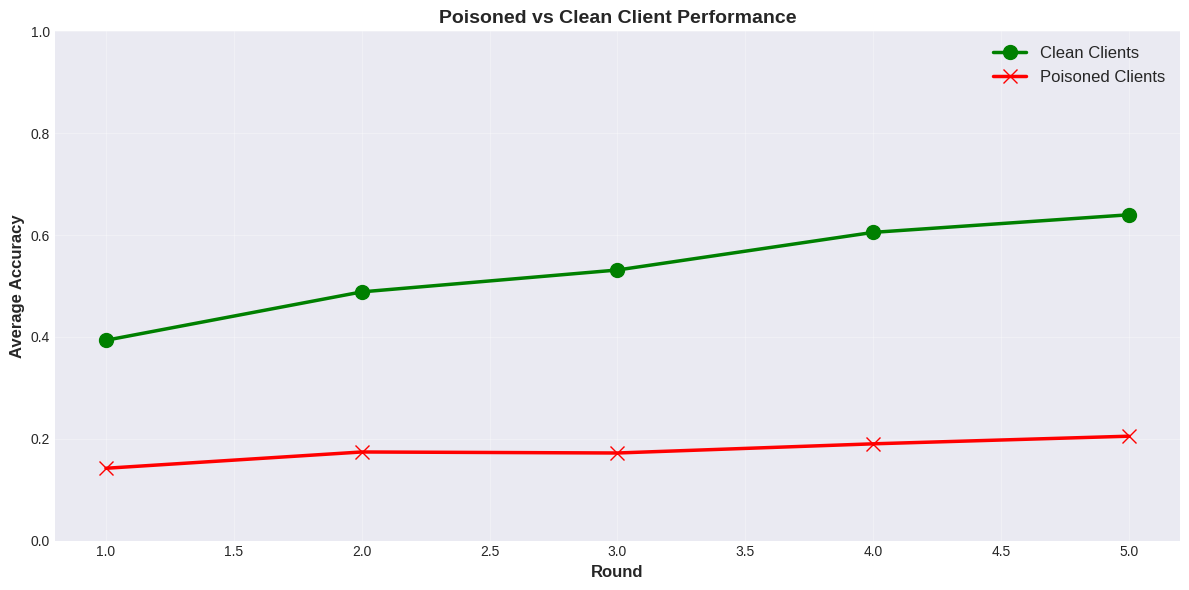

/tmp/ipython-input-3526526146.py:51: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3526526146.py:51: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3526526146.py:54: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipython-input-3526526146.py:54: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')


💾 Saved: results/attack/075flipped/plots/4_final_round_heatmap.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


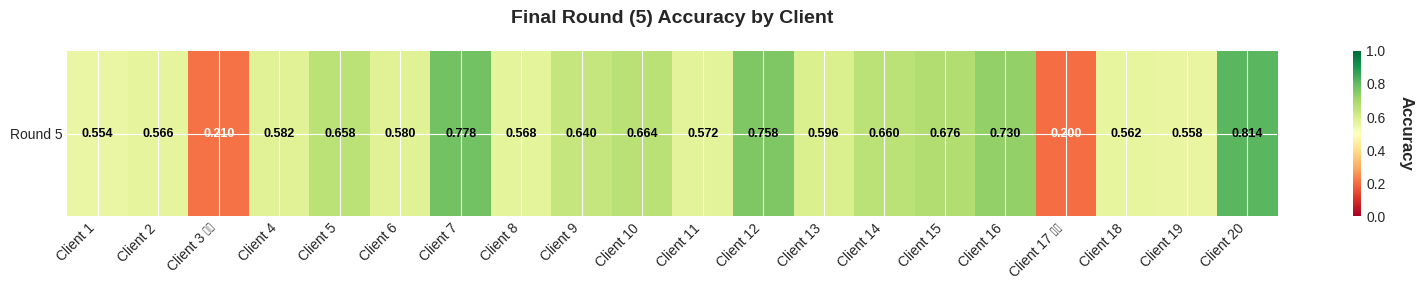

💾 Saved: results/attack/075flipped/plots/5_accuracy_distribution.png


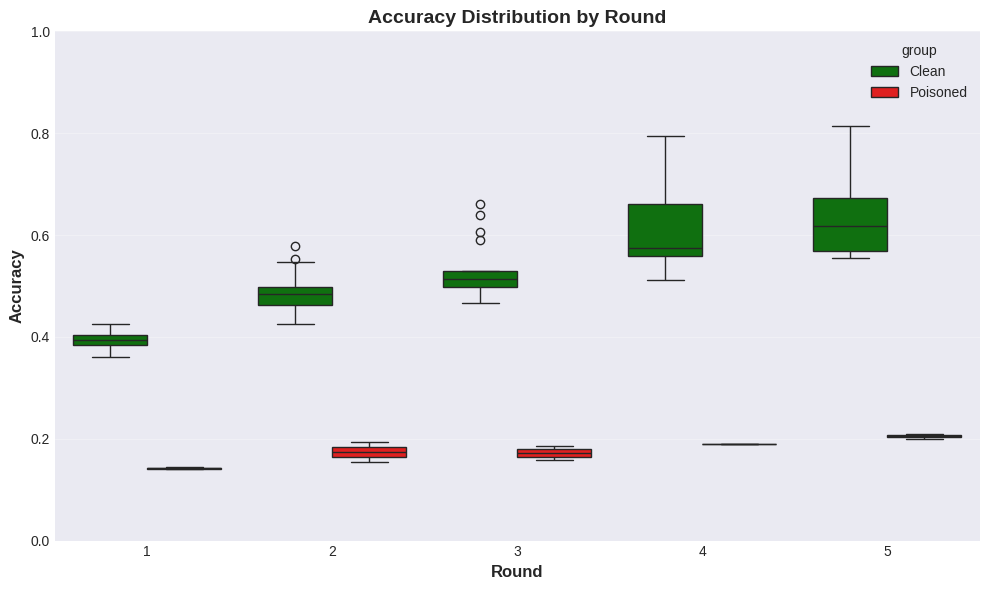

💾 Saved: results/attack/075flipped/plots/6_client_losses.png


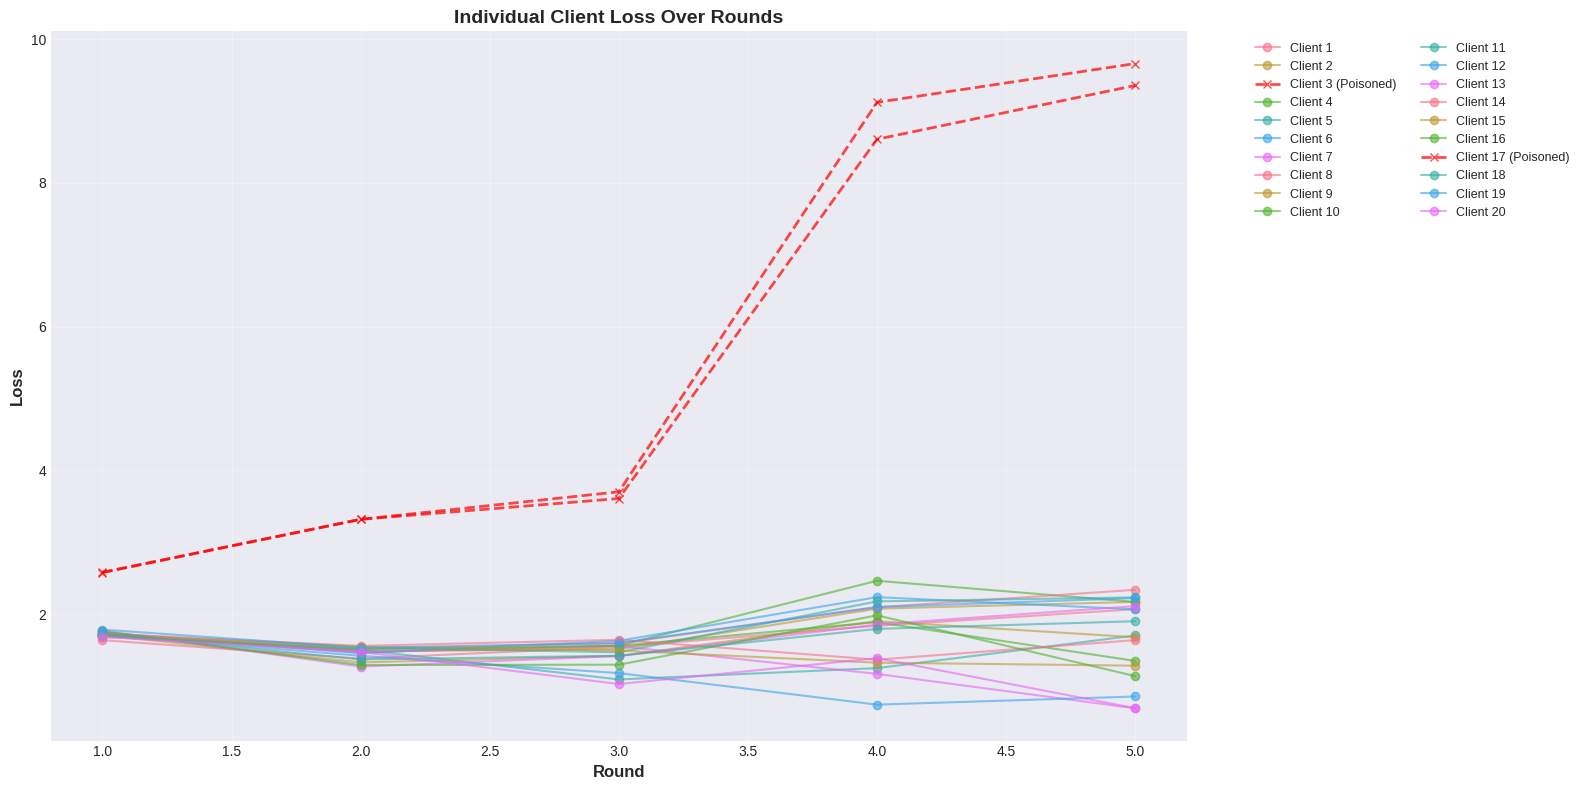


SUMMARY STATISTICS (Final Round)

🔴 Poisoned Clients (2 clients):
   Average Accuracy: 0.2050 ± 0.0071
   Min Accuracy: 0.2000
   Max Accuracy: 0.2100

🟢 Clean Clients (18 clients):
   Average Accuracy: 0.6398 ± 0.0834
   Min Accuracy: 0.5540
   Max Accuracy: 0.8140

📊 Overall (20 clients):
   Average Accuracy: 0.5963 ± 0.1554
   Min Accuracy: 0.2000
   Max Accuracy: 0.8140

✅ All plots saved to: results/attack/075flipped/plots



In [50]:
RESULTS_DIR = "results/attack/075flipped"
main()


CIFAR-10 Federated Learning Visualization

✅ Successfully loaded metrics from: results/attack/100flipped
   - Client losses: 100 records
   - Client accuracies: 100 records
   - Avg losses: 10 records
   - Avg accuracies: 5 records

📁 Saving plots to: results/attack/100flipped/plots

📊 Generating plots...

💾 Saved: results/attack/100flipped/plots/1_average_metrics.png


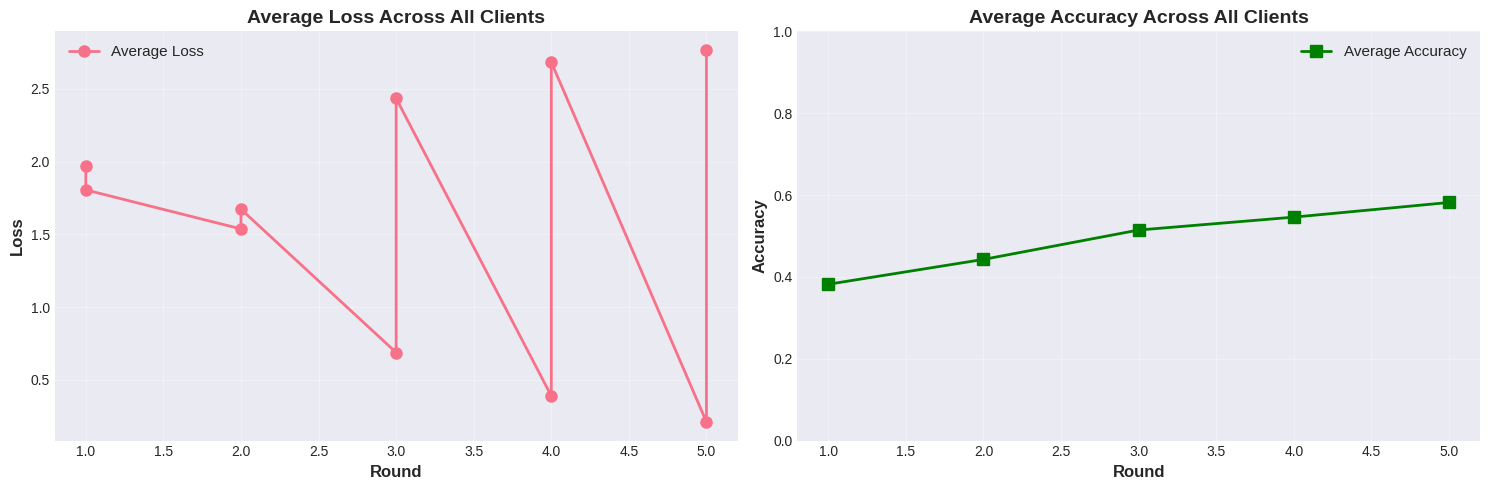

💾 Saved: results/attack/100flipped/plots/2_client_performance.png


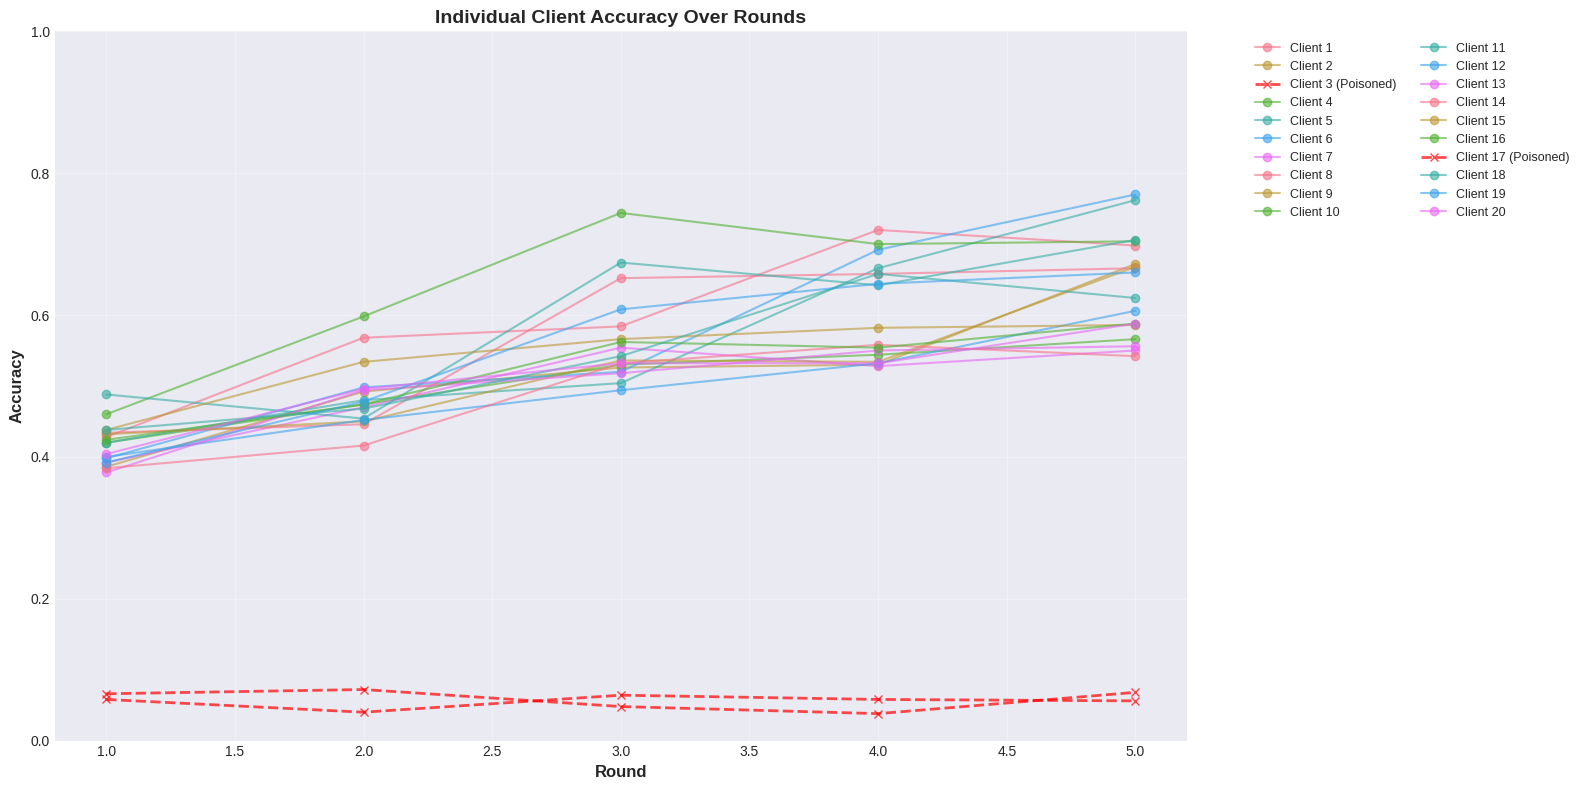

💾 Saved: results/attack/100flipped/plots/3_poisoned_vs_clean.png


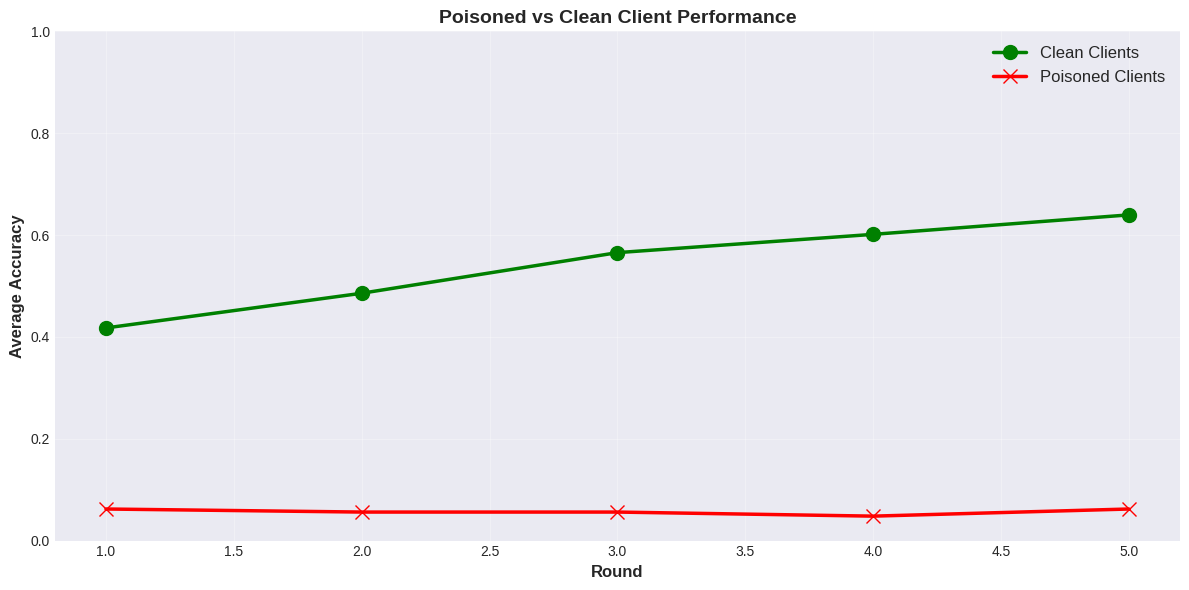

/tmp/ipython-input-3526526146.py:51: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3526526146.py:51: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3526526146.py:54: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipython-input-3526526146.py:54: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')


💾 Saved: results/attack/100flipped/plots/4_final_round_heatmap.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


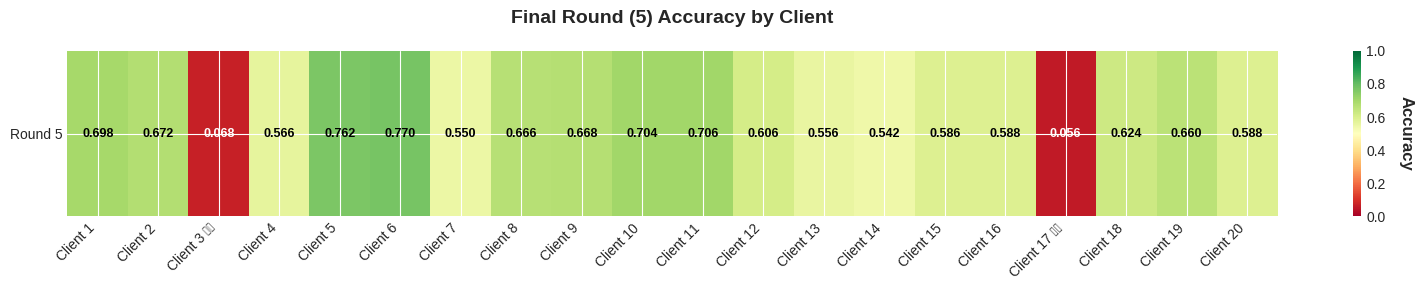

💾 Saved: results/attack/100flipped/plots/5_accuracy_distribution.png


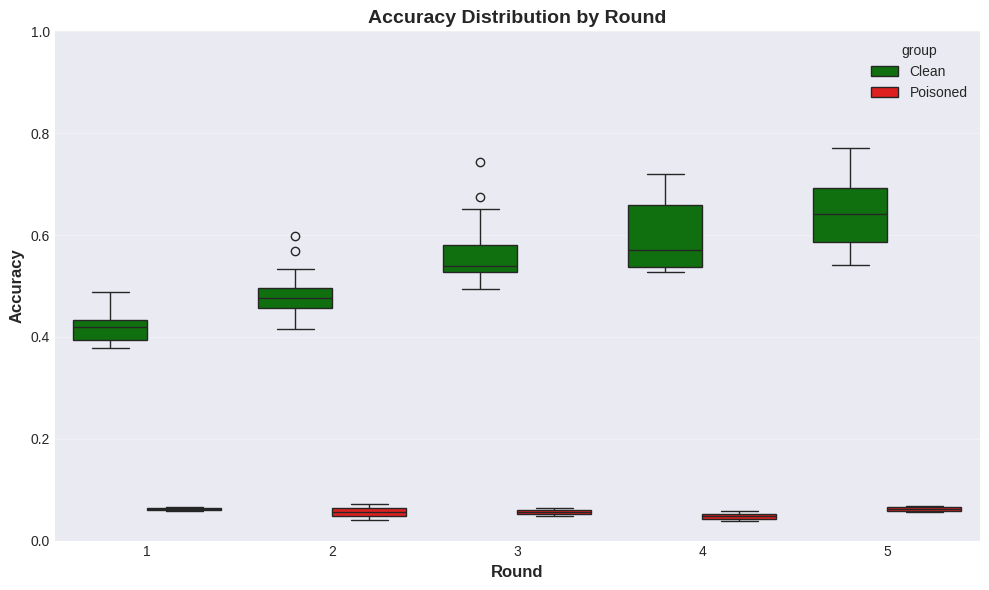

💾 Saved: results/attack/100flipped/plots/6_client_losses.png


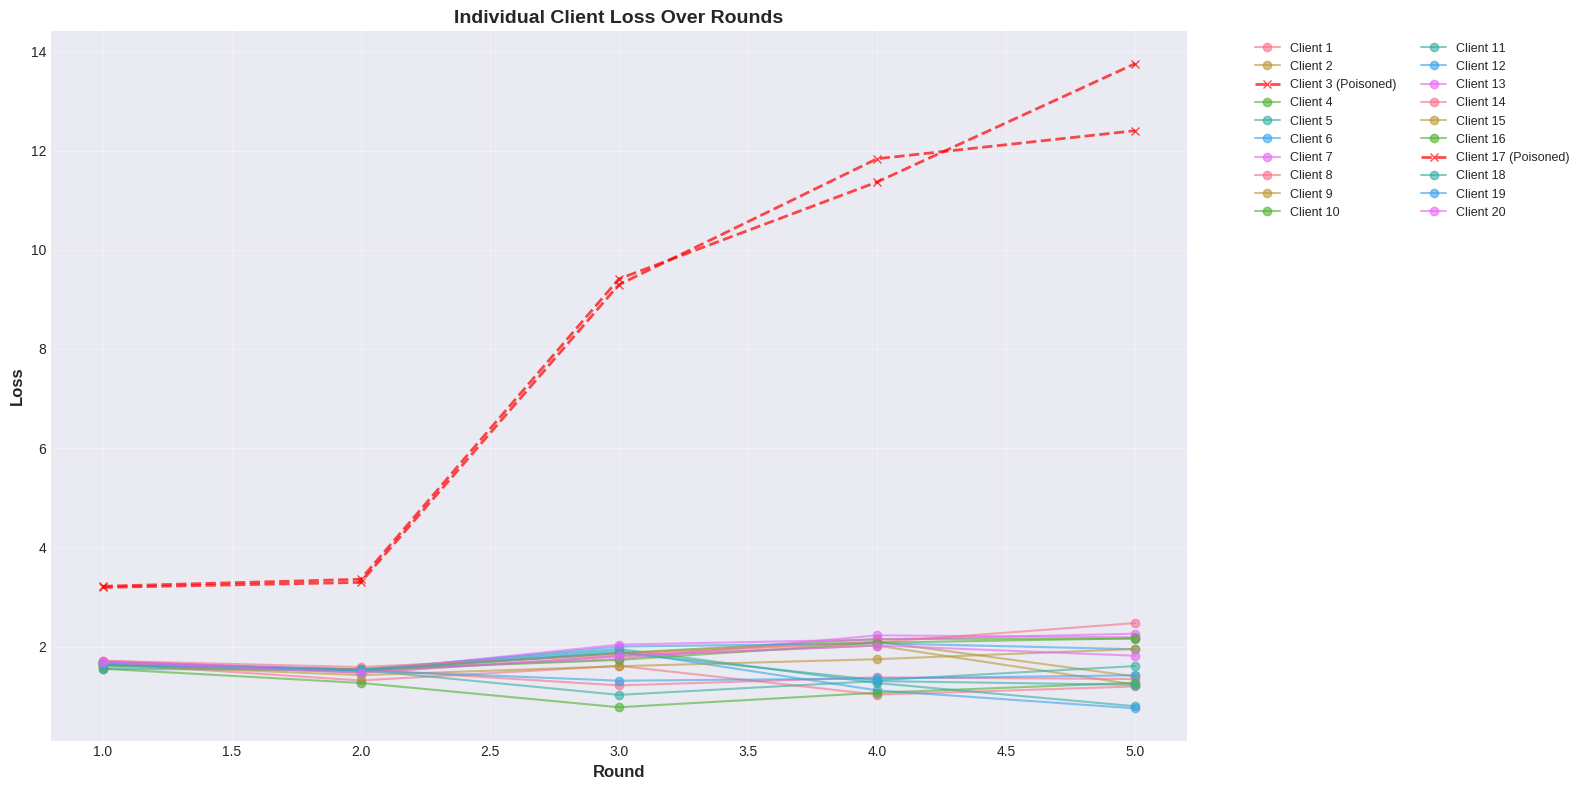


SUMMARY STATISTICS (Final Round)

🔴 Poisoned Clients (2 clients):
   Average Accuracy: 0.0620 ± 0.0085
   Min Accuracy: 0.0560
   Max Accuracy: 0.0680

🟢 Clean Clients (18 clients):
   Average Accuracy: 0.6396 ± 0.0713
   Min Accuracy: 0.5420
   Max Accuracy: 0.7700

📊 Overall (20 clients):
   Average Accuracy: 0.5818 ± 0.1901
   Min Accuracy: 0.0560
   Max Accuracy: 0.7700

✅ All plots saved to: results/attack/100flipped/plots



In [51]:
RESULTS_DIR = "results/attack/100flipped"
main()


CIFAR-10 Federated Learning Visualization

✅ Successfully loaded metrics from: results/no_attack
   - Client losses: 100 records
   - Client accuracies: 100 records
   - Avg losses: 10 records
   - Avg accuracies: 5 records

📁 Saving plots to: results/no_attack/plots

📊 Generating plots...

💾 Saved: results/no_attack/plots/1_average_metrics.png


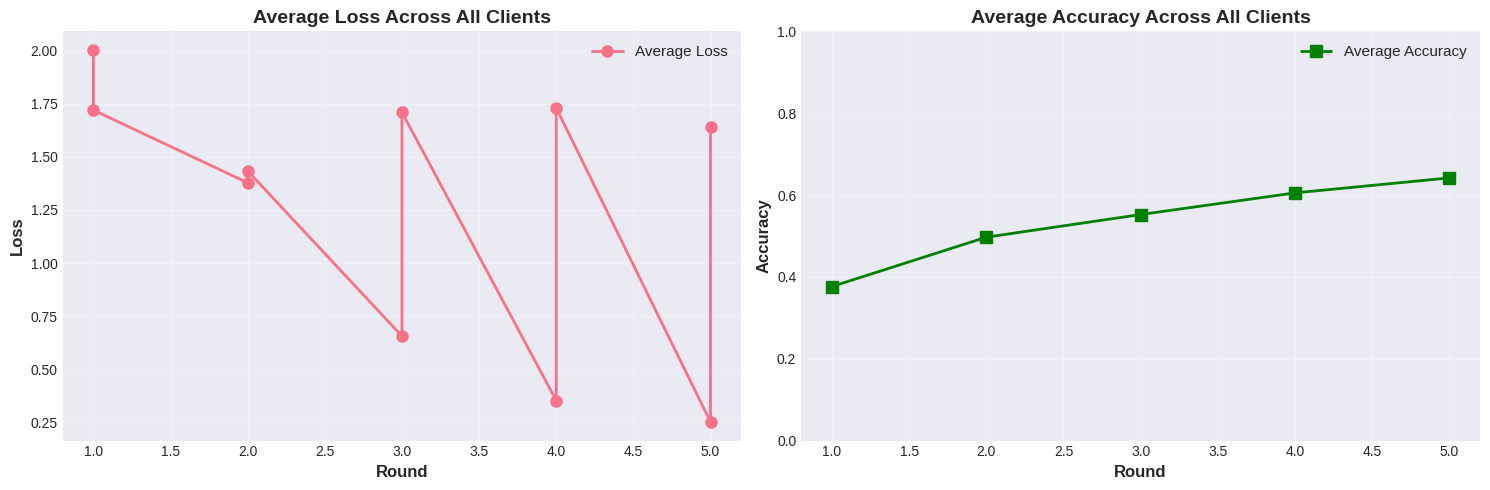

💾 Saved: results/no_attack/plots/2_client_performance.png


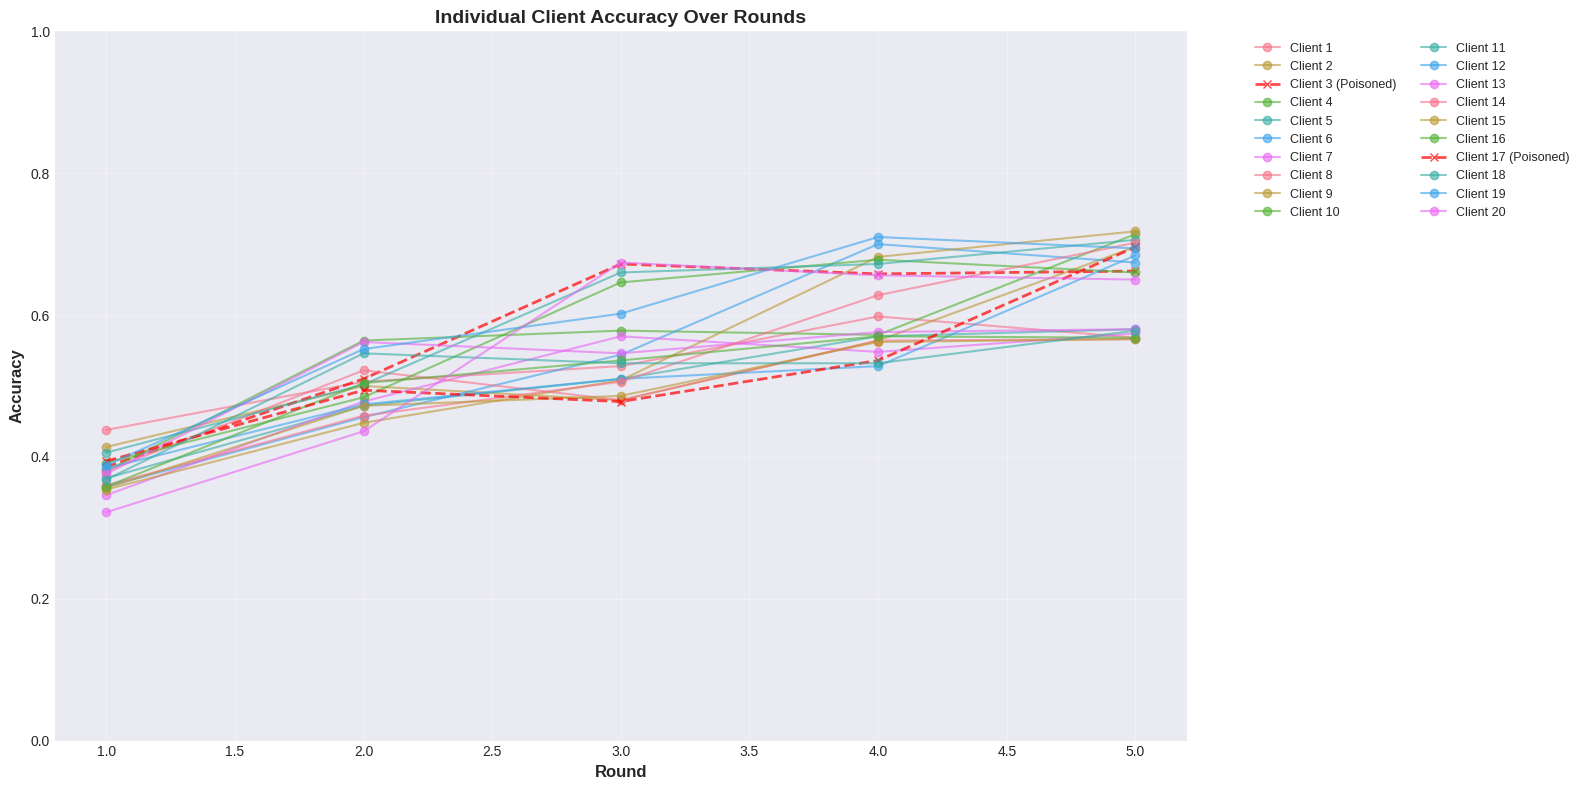

💾 Saved: results/no_attack/plots/3_poisoned_vs_clean.png


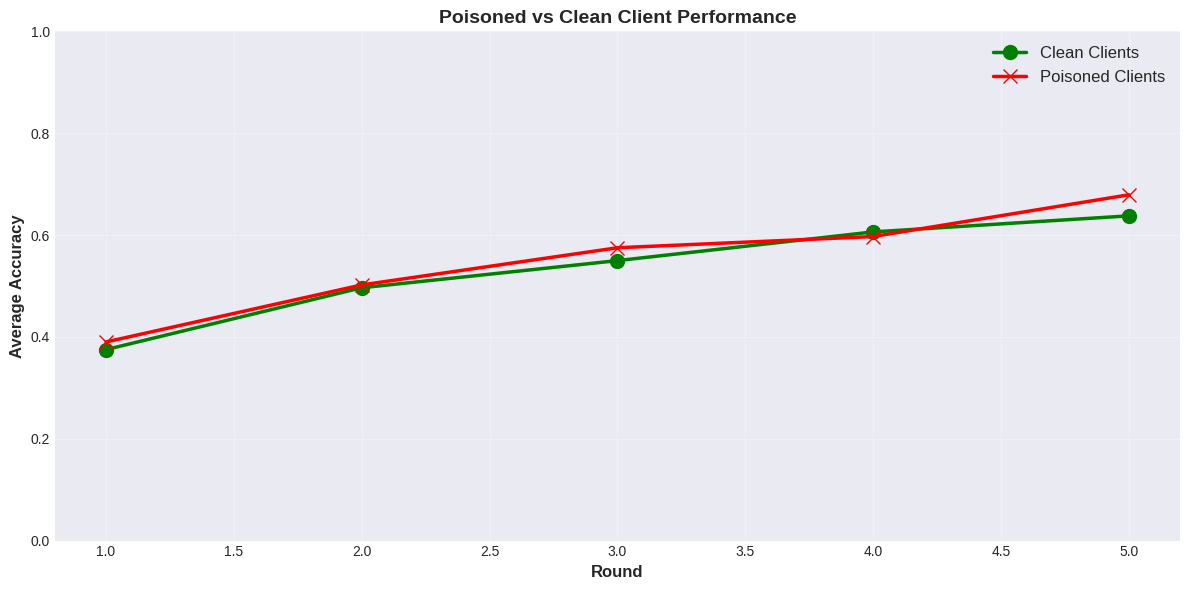

/tmp/ipython-input-3526526146.py:51: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3526526146.py:51: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3526526146.py:54: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipython-input-3526526146.py:54: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')


💾 Saved: results/no_attack/plots/4_final_round_heatmap.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


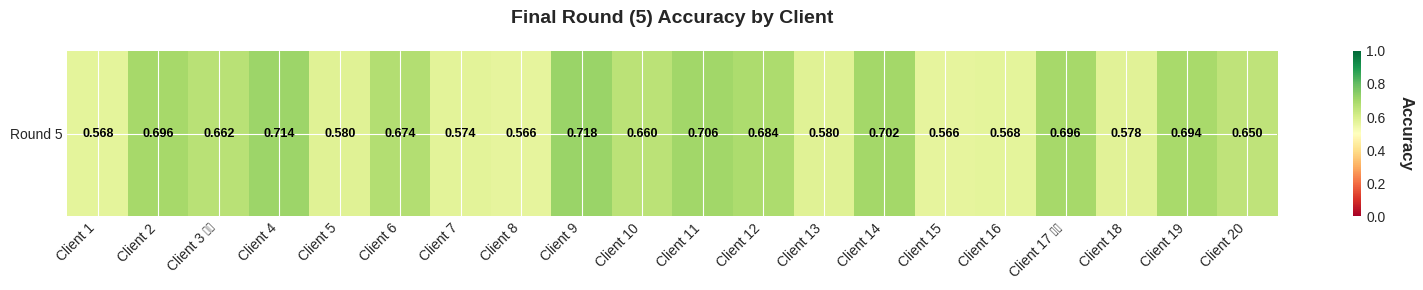

💾 Saved: results/no_attack/plots/5_accuracy_distribution.png


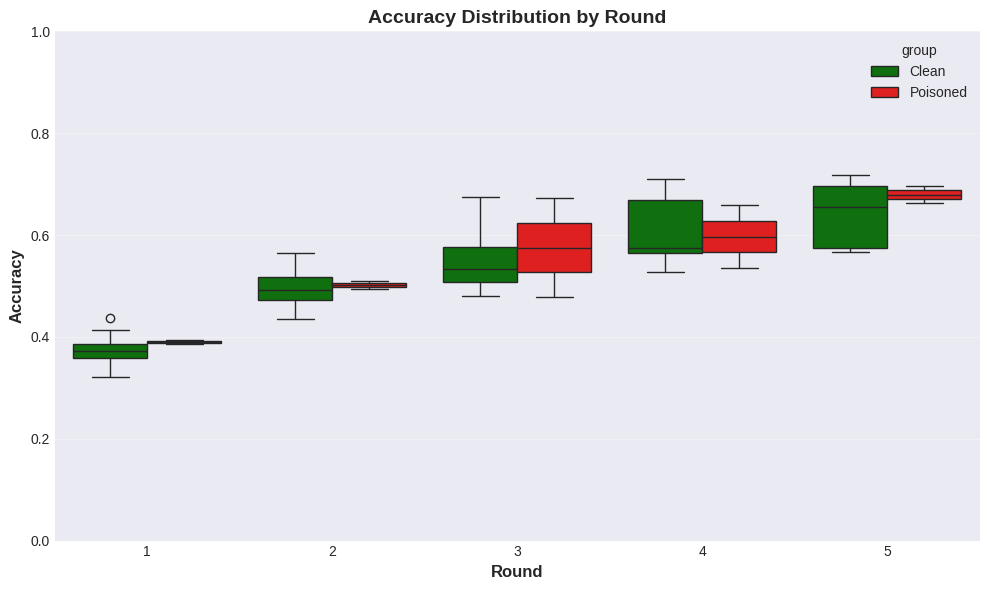

💾 Saved: results/no_attack/plots/6_client_losses.png


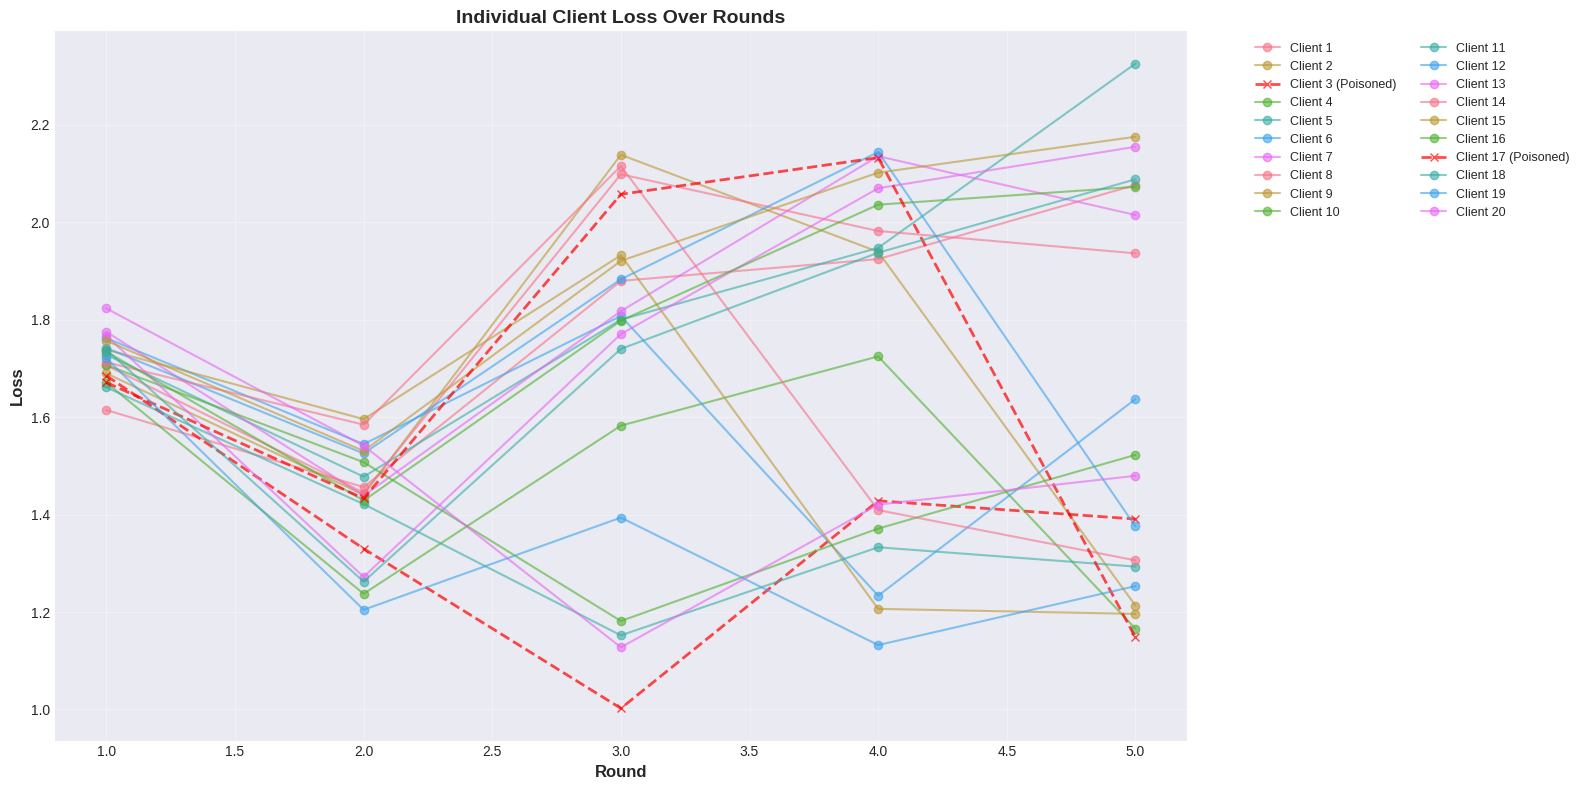


SUMMARY STATISTICS (Final Round)

🔴 Poisoned Clients (2 clients):
   Average Accuracy: 0.6790 ± 0.0240
   Min Accuracy: 0.6620
   Max Accuracy: 0.6960

🟢 Clean Clients (18 clients):
   Average Accuracy: 0.6377 ± 0.0623
   Min Accuracy: 0.5660
   Max Accuracy: 0.7180

📊 Overall (20 clients):
   Average Accuracy: 0.6418 ± 0.0606
   Min Accuracy: 0.5660
   Max Accuracy: 0.7180

✅ All plots saved to: results/no_attack/plots



In [52]:
RESULTS_DIR = "results/no_attack"
main()

In [57]:
import google.colab as c
import shutil
shutil.make_archive('results', 'zip', 'results')
c.files.download('results.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>